In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn import tree

In [3]:
df = pd.read_csv('/content/train.csv')

In [4]:
print(f"Original shape: {df.shape}")

Original shape: (1460, 81)


In [5]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

In [6]:
df = df.drop(columns=cols_to_drop, errors='ignore')

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [9]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
for col in categorical_cols:
    df[col] = df[col].fillna("Missing")

In [11]:
df_clean = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Cleaned shape: {df_clean.shape}")

Cleaned shape: (1460, 246)


In [12]:
df_clean.to_csv('/content/clean_train.csv', index=False)
print("Success! clean_train.csv has been saved to your Colab files.")

Success! clean_train.csv has been saved to your Colab files.


In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [14]:
df_model = pd.read_csv('/content/clean_train.csv')

In [15]:
X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
dt_regressor = DecisionTreeRegressor(random_state=42)

In [18]:
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

In [19]:
print("Training model and searching for best hyperparameters...")
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

Training model and searching for best hyperparameters...


In [20]:
grid_search.fit(X_train, y_train)
best_dt_model = grid_search.best_estimator_

In [21]:
y_pred = best_dt_model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [25]:
print("\n--- My Decision Tree Performance ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")


--- My Decision Tree Performance ---
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Mean Absolute Error (MAE): 23994.17
Root Mean Squared Error (RMSE): 38825.09
R-squared (R2): 0.8035


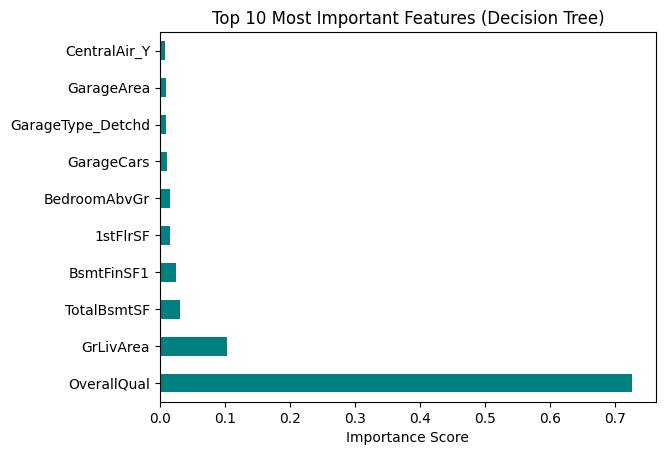

In [26]:
feature_importances = pd.Series(best_dt_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()